# 🧠 Entrenando tu primer LLM desde cero

En este notebook vas a construir y entrenar un **modelo de lenguaje** (**LLM**) desde cero, línea por línea, sin cajas negras.

No usaremos modelos pre-entrenados — vamos a construir la arquitectura nosotros mismos con **PyTorch** y entrenarla en un texto simple.

### ¿Qué vamos a construir?

Un **mini-GPT**: un modelo Transformer decoder-only que aprende a predecir el siguiente carácter dado un contexto.  
Es la misma arquitectura que GPT-2/3/4, sólo que mucho más pequeña.

### ¿Qué aprenderás?

| Sección | Concepto |
|---|---|
| 1 | Instalación de dependencias (Mac / Linux / Windows) |
| 2 | Tokenización a nivel de carácter |
| 3 | Preparación del dataset con ventana deslizante |
| 4 | Embeddings de tokens y posición |
| 5 | Self-Attention y Multi-Head Attention |
| 6 | Bloque Transformer completo |
| 7 | Modelo GPT-like ensamblado |
| 8 | Loop de entrenamiento con AdamW |
| 9 | Gráfica de la pérdida |
| 10 | Generación de texto (inferencia) |
| 11 | Perplexity como métrica de calidad |
| 12 | Experimentos para mejorar el modelo |

.
> **Prerequisito:** Python 3.9+. No se necesita GPU — el modelo es tan pequeño que corre en CPU en minutos.

---
## 1. Instalación de dependencias

Necesitamos **PyTorch**, **Matplotlib** y **tiktoken** (el tokenizador BPE de OpenAI).

---

### 🍎 Mac con Apple Silicon (M1 / M2 / M3 / M4)

```bash
pip install torch torchvision torchaudio tiktoken matplotlib
```

> La aceleración MPS se activa automáticamente con `device = "mps"`.

---

### 🍎 Mac con Intel

```bash
pip install torch torchvision torchaudio tiktoken matplotlib
```

---

### 🐧 Linux (CPU)

```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
pip install tiktoken matplotlib
```

### 🐧 Linux (GPU NVIDIA — CUDA 12.1)

```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
pip install tiktoken matplotlib
```

---

### 🪟 Windows (CPU)

```powershell
pip install torch torchvision torchaudio tiktoken matplotlib
```

### 🪟 Windows (GPU NVIDIA — CUDA 12.1)

```powershell
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
pip install tiktoken matplotlib
```

### 🪟 Windows con Conda (recomendado en Windows)

```powershell
conda install pytorch torchvision torchaudio pytorch-cuda=12.1 -c pytorch -c nvidia
conda install matplotlib
pip install tiktoken
```

---

> 📌 Verificá siempre la versión correcta de CUDA en [pytorch.org/get-started](https://pytorch.org/get-started/locally/)


In [ ]:
#import subprocess, sys

# Instala las dependencias mínimas requeridas para este notebook
#subprocess.run(
#    [sys.executable, "-m", "pip", "install", "torch", "tiktoken", "matplotlib", "--quiet"],
#    check=True
#)
#print("✅ Instalación completada")


---
## 2. Verificar instalación y detectar dispositivo

Primero verificamos que PyTorch esté instalado y detectamos qué acelerador de hardware tenemos disponible:

| Dispositivo | Significado |
|---|---|
| `cpu` | Solo procesador — funciona siempre, más lento |
| `mps` | Apple Silicon GPU via Metal — Mac M1/M2/M3/M4 |
| `cuda` | GPU NVIDIA — el más rápido para deep learning |

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math, time, random

print(f"✅ PyTorch versión : {torch.__version__}")
print()

# Detectar el mejor dispositivo disponible
if torch.cuda.is_available():
    device = torch.device("cuda")
    nombre_gpu = torch.cuda.get_device_name(0)
    memoria_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"🟢 NVIDIA GPU disponible: {nombre_gpu} ({memoria_gb:.1f} GB VRAM)")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🟢 Apple Silicon GPU (Metal MPS) disponible")
else:
    device = torch.device("cpu")
    print("🔵 Usando CPU (sin GPU disponible)")

print(f"\n📍 Dispositivo seleccionado: {device}")
print("   Este notebook corre bien en CPU — el modelo es pequeño a propósito.")

✅ PyTorch versión : 2.11.0

🟢 Apple Silicon GPU (Metal MPS) disponible

📍 Dispositivo seleccionado: mps
   Este notebook corre bien en CPU — el modelo es pequeño a propósito.


---
## 3. El dataset: ¿qué texto va a aprender el modelo?

Para que el entrenamiento sea rápido y comprensible, usaremos un texto corto directamente en el código.  
El modelo aprenderá a **reproducir y continuar** el estilo de ese texto.

### ¿Por qué un texto corto?

- Un texto de ~2000 caracteres tarda segundos en entrenar (no horas)
- Podés ver el resultado inmediatamente
- Los conceptos son 100% iguales que con datasets de millones de tokens

### ¿Qué texto usamos?

Usamos un texto sobre inteligencia artificial. El modelo aprenderá a generar texto similar.  
Podés reemplazar `TEXTO` con cualquier contenido que quieras (un libro, código, letras de canciones).

> 💡 **Regla práctica:** Para que un modelo character-level aprenda algo útil,  
> necesitás al menos 100x más caracteres que parámetros del modelo.

In [18]:
# El texto que el modelo aprenderá a imitar
# Puedes reemplazarlo con cualquier texto (más texto = mejor resultado)
TEXTO = """
Manual de Analisis Estrategico

Este manual presenta una introduccion integral al analisis estrategico del negocio y describe como pasar del escenario general a la formulacion de una estrategia concreta, y de la estrategia a la accion y al control. La idea central es que la estrategia no debe quedar como una declaracion abstracta, sino convertirse en un sistema de gestion que conecte el diagnostico, las decisiones, los objetivos, los indicadores, los planes de accion y el seguimiento. A lo largo de este recorrido se parte de preguntas fundamentales sobre la identidad y el entorno de la empresa, y se llega a la construccion de un modelo de negocio gestionable por medio del Cuadro de Mando Integral o Balanced Scorecard.

Desde el comienzo se organiza el analisis estrategico en fases secuenciales. Primero defino la idea del negocio por medio de la mision y los valores. Despues aclaro el estado actual de la empresa y sus objetivos futuros a traves de la vision. Luego describo el mercado, estudio la situacion competitiva, realizo el analisis FODA y, a partir de ese trabajo, formulo la estrategia. Una vez formulada, traduzco esa estrategia en objetivos estrategicos, indicadores, un plan de negocios y un sistema de seguimiento del grado de cumplimiento de metas, objetivos y estrategias. En este enfoque sostengo que una empresa no puede gestionar bien si no responde con precision para que existe, donde esta parada, que quiere llegar a ser, como es su mercado, quienes son sus competidores, que factores la favorecen o la perjudican y como deberia avanzar.

Uno de los ejes principales es el Balanced Scorecard como puente entre la formulacion estrategica y la ejecucion. Se presenta el Cuadro de Mando Integral como una forma de clasificar y ordenar los objetivos estrategicos en cuatro grandes perspectivas: financiera, cliente, procesos internos, y aprendizaje y crecimiento. Desde la perspectiva financiera explico como debe verse la empresa ante el accionista si tiene exito. Desde la perspectiva del cliente muestro como debe ser percibida para ser elegida. Desde la perspectiva de procesos internos identifico en que procesos debe destacarse la organizacion para satisfacer al cliente. Finalmente, desde la perspectiva de aprendizaje y crecimiento describo la capacidad de la empresa para aprender, mejorar, desarrollar personas, fortalecer habilidades y sostener el cambio.

Se destaca que estas perspectivas no son compartimentos aislados, sino partes de una cadena de relaciones de causa y efecto. Cuando se desarrollan capacidades y condiciones de aprendizaje y crecimiento, mejoran los procesos internos; cuando los procesos se ejecutan bien, mejora la propuesta de valor al cliente; y cuando mejora la percepcion del cliente, se traducen mejores resultados financieros. Por esto se enfatiza el mapa estrategico: permite mostrar de manera grafica como se conectan objetivos, impulsores e indicadores. Asi, la estrategia deja de ser una lista desordenada de deseos y pasa a convertirse en una arquitectura causal.

Se presenta esta logica a traves del contraste entre dos orientaciones estrategicas complementarias: la estrategia de crecimiento y la estrategia de productividad. En relacion al crecimiento, se pone el foco en comprender mejor las necesidades de los clientes y en mejorar la calidad de los ingresos por medio de una propuesta de valor diferenciada. En relacion a la productividad, se concentra la atencion en maximizar la utilizacion de los activos y reducir costos de operacion. Con esto se muestra que una empresa madura necesita equilibrar ambas dimensiones: crecer sin descuidar la eficiencia, y mejorar la eficiencia sin deteriorar el valor que percibe el cliente. A partir de ahi se vincula la estrategia con indicadores concretos como rentabilidad, cash flow, satisfaccion del cliente, calidad de entrega, servicio postventa, innovacion, excelencia operativa, reduccion de fallas, uso de activos, motivacion del personal y conocimiento estrategico.

En la construccion del Cuadro de Mando Integral se propone una serie de pasos. Primero se marca la cancha por medio de la definicion de la mision y los valores compartidos. Luego se define la vision, es decir, el horizonte al que se quiere llegar. Despues se analiza el entorno y la empresa mediante herramientas como PEST, el estudio del mercado y el FODA. Mas tarde se formula la estrategia identificando temas estrategicos, actividades estrategicas, trade-offs y fit drivers. Recien entonces se describen las perspectivas, se definen objetivos estrategicos, impulsores e indicadores, se dibuja el mapa estrategico, se detallan indicadores, se fijan metas, se confecciona el mapa de control, se definen las iniciativas estrategicas y finalmente se controla la ejecucion de los programas. Con esta secuencia se establece una idea de gestion disciplinada: antes de medir, se piensa; antes de actuar, se elige; antes de exigir resultados, se aclara el rumbo.

Se dedica un espacio importante a la actitud que se considera necesaria durante todo el proceso. Se va mas alla de la aplicacion de herramientas tecnicas, sino que se propone crear una dinamica organizacional adecuada. Por eso se destaca la importancia de definir cuantas personas deben participar, priorizar la proactividad, trabajar de forma coordinada y escuchar con respeto las opiniones ajenas. En este manual se presenta la estrategia no como un ejercicio solitario de alta direccion, sino como un proceso que necesita inteligencia colectiva, capacidad de escucha, alineamiento y compromiso.

Cuando se aborda la mision, se parte de una pregunta rectora: para que existe la organizacion. Se explica que la mision expresa la funcion o tarea basica de la organizacion y que no debe confundirse con una frase vaga o meramente aspiracional. Desde esta perspectiva, una buena mision comunica por que la empresa es especial o diferente y, sobre todo, define el negocio en el que quiere estar, no solamente aquel en el que ya esta. Por esto se insiste en evitar descripciones estrechas del producto y en pensar la necesidad que realmente se satisface.

Al redactar correctamente la mision, se incluyen varios elementos. Primero, se describen los productos y servicios ofrecidos. Se aclara, sin embargo, que pueden describirse desde la oferta, con una orientacion al producto, o desde la demanda, con una orientacion al mercado. Segundo, se define el mercado al que se dirige la empresa y el ambito geografico al que llegara. Aqui se considera clave la segmentacion, porque la mision debe decir con suficiente precision a que clientes servira la empresa y en que espacio geografico actuara. Tercero, se describen las caracteristicas diferenciales frente a la competencia, es decir, aquellas competencias tecnologicas, operativas o comerciales que explican por que el cliente elegira a la empresa y no a otra. Los ejemplos que se incorporan responden justamente a esta logica: muestran con claridad el producto, el segmento y el factor distintivo.

En el apartado sobre valores se responde a la pregunta sobre lo que se cree fundamentalmente. Se presentan los valores como creencias y convicciones basicas que orientan las decisiones, el trabajo y la conducta colectiva. De manera fundamental no son adornos retoricos, sino ejes de comportamiento que guian las reflexiones y las actuaciones del grupo. Por esto se incluyen ejemplos de valores corporativos como orientacion al cliente, disciplina, calidad, toma de riesgos, confianza en las personas, trabajo en equipo, aprendizaje a partir de errores, entusiasmo, honestidad, integridad, justicia y transparencia. El mensaje de fondo que se establece es claro: una estrategia solo puede sostenerse en el tiempo si esta respaldada por valores compartidos que moldeen la cultura de la organizacion.

La vision, tal como se presenta, responde a la pregunta sobre la maxima aspiracion de la empresa. Se define como un objetivo inspirador de largo plazo, capaz de englobar al resto de los objetivos. Desde esta mirada, una buena vision va mucho mas alla de simples metas financieras porque debe capturar tanto la razon como la emocion de los empleados. Su funcion es crear sentido, orientar esfuerzos y servir como referencia para las decisiones. En consecuencia, se explica que una empresa no se moviliza solo por un presupuesto o por una meta de ventas, sino por una imagen futura clara y deseable de lo que quiere llegar a ser.

Una vez definidos mision, valores y vision, se introduce el analisis FODA. Se presenta como una herramienta que permite construir un cuadro de situacion actual de la empresa para obtener un diagnostico preciso y tomar decisiones coherentes con los objetivos. En este manual se deja claro que el FODA no se limita a una lista informal de puntos buenos y malos, sino que se apoya en el estudio de dos grandes ambientes: el interno y el externo. Dentro del entorno externo incluyo el macroentorno y la industria. En el macroentorno ubico factores economicos, tecnologicos, socioculturales y politicos-legales. En la industria analizo clientes, proveedores, competencia actual, productos sustitutos, nuevos competidores y cadena de distribucion. En el entorno interno considero management, valores, produccion, creencias, gestion financiera, objetivos e incentivos, recursos humanos y calidad.

Dentro del analisis externo tambien se presenta el mapa de grupos estrategicos como herramienta para visualizar la posicion competitiva de los actores de una industria. El objetivo aqui es agrupar empresas rivales con enfoques y posiciones competitivas similares y ubicarlas en un mapa construido con variables relevantes, por ejemplo amplitud de linea, atributos del producto o canales de distribucion. Con esto se explica que la competencia no es homogenea: en una misma industria pueden coexistir grupos que compiten de formas muy distintas, con propuestas de valor diferentes y con barreras especificas entre posiciones.

Para volver mas concreto el analisis, se incluyen ejemplos de oportunidades y amenazas. Entre las oportunidades se menciona el mayor interes por los productos ofrecidos, necesidades insatisfechas en otras geografias, beneficios fiscales, mejora de la economia regional, cambios favorables en los habitos de consumo, rivales en dificultades, nuevas tecnologias y aumento de la demanda. Entre las amenazas se señalan nuevos competidores potenciales, sustitutos, menor crecimiento del mercado, mayor presion tributaria, trabas arancelarias, nuevos costos regulatorios, recesion en el ciclo de vida del negocio, mayor poder de clientes y proveedores, cambios en gustos y preferencias y transformaciones demograficas. Con estos ejemplos se busca mostrar que la estrategia debe nacer de una lectura concreta del contexto y no de deseos desconectados de la realidad.

En cuanto al analisis interno, se explica que se debe buscar fortalezas y debilidades revisando el funcionamiento de la estrategia actual, la cadena de valor, los costos y la competitividad respecto de los rivales, y el poder competitivo general. Para ello se introduce el modelo de las 7S de McKinsey, que se utiliza como una lista de verificacion para ejecutar con exito la estrategia. Las siete dimensiones son estructura, sistemas, estilo, personal, metas superiores, estrategia y habilidades. La idea central que se destaca es que estos elementos actuan en forma integrada y que descuidar uno puede volver lento, ineficaz o incluso fatal el proceso de cambio. Desde esta perspectiva, la estrategia no se implementa solo con un organigrama o con una orden de direccion; necesita coherencia entre estructura, cultura, personas, procesos, capacidades y objetivos superiores.

Se incorpora la evaluacion competitiva de la empresa a traves de factores tangibles e intangibles. Entre los tangibles se consideran las distintas areas funcionales, como sistemas, produccion, comercial, administracion, finanzas y direccion. Entre los intangibles se destaca marca, prestigio, innovacion, creatividad y conciencia estrategica. Al hacerlo, se busca recordar que la competitividad no depende solo de recursos fisicos o financieros; tambien depende de activos menos visibles pero decisivos, como la reputacion, el conocimiento o la capacidad de innovar.

La cadena de valor ocupa un lugar central en este analisis. Se distinguen actividades primarias y actividades de apoyo, y se muestra que el margen de la empresa surge del valor agregado a lo largo de operaciones, logistica de entrada, logistica de salida, marketing y ventas, servicios, infraestructura, compras, administracion de recursos humanos y desarrollo tecnologico. Cuando se analiza la cadena de valor, se hace para detectar donde se crea valor, donde hay ineficiencias, donde existen ventajas frente a la competencia y donde conviene intervenir para mejorar costos o diferenciacion.

En la enumeracion de fortalezas y debilidades se presentan ejemplos concretos. Como fortalezas posibles se menciona una estrategia solida, una administracion financiera sana, buena imagen y reputacion, economias de escala, excelencia tecnologica, ventaja de costos, personal capacitado, innovacion, buen servicio y alta calidad. Como debilidades se enumeran la falta de claridad estrategica en la direccion, tecnologia inexistente u obsoleta, exceso de deuda, costos superiores a los competidores, debilidad administrativa, baja rentabilidad, problemas productivos, rezagos en investigacion y desarrollo, capacidad ociosa y mala imagen. Con esta parte se busca convertir ideas abstractas en elementos observables para el diagnostico.

Una vez identificadas fortalezas, debilidades, oportunidades y amenazas, se muestra como se combinan esos factores para definir estrategias. La matriz FODA permite pensar estrategias O-F para maximizar oportunidades apoyandose en fortalezas; estrategias A-F para usar fortalezas y reducir amenazas; estrategias O-D para aprovechar oportunidades minimizando debilidades; y estrategias A-D para reducir al mismo tiempo amenazas y debilidades. El punto que se refuerza aqui es que la estrategia no consiste solo en detectar problemas, sino en elegir la mejor combinacion posible entre capacidades internas y condiciones externas.

Mas adelante se aborda la definicion misma de estrategia. Se explica que el termino proviene del ambito militar, pero que en administracion implica la adaptacion de recursos y habilidades al entorno cambiante, aprovechando oportunidades y evaluando riesgos en funcion de objetivos y metas. Se distinguen tambien cuatro niveles estrategicos: corporativo, de negocio, funcional y operativo. Con esta diferenciacion se ordenan las decisiones, porque no es lo mismo definir en que negocios competir, que decidir como ganar en un negocio concreto, que determinar como debera actuar cada area, o como se traducira todo eso en practicas operativas diarias.

Se dedica un espacio destacado a las estrategias genericas de Michael Porter. Se presentan tres grandes alternativas: liderazgo en costos, diferenciacion y enfoque. Cuando se explica el liderazgo en costos, se señala que consiste en controlar los impulsores del costo o reformular la cadena de valor para ofrecer bajos precios o conservar mayores margenes. Se indica que es especialmente util en mercados sensibles al precio, siempre que la ventaja no sea facil de imitar. Cuando se desarrolla la diferenciacion, se muestra que busca distinguirse por calidad, innovacion, diseno, know how, servicio, marca o canal. Se explica que es adecuada en mercados donde las preferencias son diversas y que permite cobrar un precio extra, vender mas unidades o generar lealtad de marca. Por ultimo, cuando se presenta la estrategia de enfoque, se la define como la especializacion en un segmento o nicho de mercado y en el conocimiento profundo de sus necesidades. Se aclara que este nicho debe ser suficientemente atractivo y que la empresa debe contar con recursos y capacidades para atenderlo mejor que los rivales generalistas.

Otra seccion importante que se desarrolla es la de factores claves del exito. Se definen como caracteristicas que tienen relacion directa con el rendimiento de la empresa y que funcionan como requisitos previos para la supervivencia y el exito dentro de la industria. Para identificarlos, se propone analizar que base utilizan los clientes para elegir entre marcas, que debe hacer una empresa para tener exito competitivo, y que recursos, habilidades o capacidades necesita para construir una ventaja competitiva sostenible. Se aclara tambien que los factores claves cambian segun la industria y el momento, y que por lo general son pocos, entre tres y cuatro. Con esto se busca concentrar la atencion en lo verdaderamente decisivo y evitar la dispersion.

En continuidad con ello, se definen las actividades estrategicas como aquellas actividades clave para el exito que se ejecutan de una forma distinta a la de los rivales. Aqui se retoma una idea central: la esencia de la estrategia es ser diferente. No alcanza con hacer lo mismo que todos de manera apenas mas eficiente. Es necesario elegir actividades que constituyan una fuente real de ventaja. En este punto se introducen dos conceptos complementarios. El primero son los trade-offs, que recuerdan que toda estrategia implica decidir que no se va a hacer; elegir un camino supone renunciar a otros. El segundo son los fit drivers, es decir, los ajustes necesarios en la organizacion y en los procesos para que las actividades estrategicas puedan ejecutarse con el nivel de desempeño esperado. En otras palabras, no basta con definir una ventaja; tambien es necesario alinear la empresa para sostenerla.

Hacia el final se integra todo en la logica del modelo de negocio. Se plantea que un negocio orientado a concretar la vision se estructura a partir de relaciones causales entre resultados financieros esperados, propuesta de valor para el cliente, procesos criticos y condiciones necesarias para el crecimiento. Se describe luego otra forma de comprender ese modelo estrategico: por un lado, el modelo financiero del negocio, es decir, que objetivos financieros deben lograrse para que la empresa sea viable; por otro, la percepcion del cliente, o sea como debe vernos en precio, calidad, facilidad de acceso, funcionalidad, servicio e imagen; luego los procesos criticos, que deben estar disenados para sostener esos resultados; y finalmente las condiciones necesarias, como recursos humanos, tecnologias y alianzas estrategicas.

En las conclusiones se sintetiza el mensaje principal con claridad. En primer lugar, se establece que sin planificacion estrategica no puede haber un Cuadro de Mando Integral serio. En segundo lugar, se destaca que vision, mision y valores constituyen el marco de referencia indispensable de toda estrategia. En tercer lugar, se subraya que el analisis del macroentorno y del microentorno es imprescindible para definir correctamente el rumbo. Y, por ultimo, se enfatiza una diferencia decisiva: la eficacia operativa no es estrategia. Ser eficiente, reducir errores o hacer mejor lo que ya se hace puede ser necesario, pero no alcanza. La estrategia exige ser distinto a los rivales, construir una posicion propia y sostenerla con decisiones coherentes.

En sintesis, este manual presenta una mirada completa, ordenada y profundamente practica sobre la direccion estrategica. A lo largo del desarrollo se muestra que formular estrategia implica comprender la identidad de la organizacion, leer el entorno, diagnosticar sus capacidades, elegir un posicionamiento, traducirlo a objetivos e indicadores y crear mecanismos de seguimiento. Se establece tambien una enseñanza de fondo: la estrategia no es solo una herramienta analitica, sino una forma de alinear pensamiento, decisiones, personas y procesos alrededor de un futuro deseado. Por esto, este manual funciona como una guia para convertir la reflexion estrategica en gestion concreta y sostenida.
"""

print(f"📄 Texto cargado:")
print(f"   Total de caracteres : {len(TEXTO):,}")
print(f"   Total de palabras   : {len(TEXTO.split()):,}")
print(f"\nPrimeros 200 caracteres:")
print(f"{'─'*50}")
print(TEXTO[:200])

📄 Texto cargado:
   Total de caracteres : 19,936
   Total de palabras   : 3,029

Primeros 200 caracteres:
──────────────────────────────────────────────────

Manual de Analisis Estrategico

Este manual presenta una introduccion integral al analisis estrategico del negocio y describe como pasar del escenario general a la formulacion de una estrategia concr


---
## 4. Tokenización BPE: de texto a números

Los modelos no entienden palabras — solo **números**.  
La **tokenización** convierte texto en una secuencia de enteros.

### Tipos de tokenización

| Tipo | Unidad | Vocabulario | Ejemplo |
|---|---|---|---|
| Character-level | 1 carácter | ~100 tokens | `h`, `o`, `l`, `a` |
| Word-level | 1 palabra | ~50,000 tokens | `hola`, `mundo` |
| **BPE (subword)** ← **usamos este** | fragmentos | ~50,000 tokens | `hol`, `##a` |
| SentencePiece | subpalabras | variable | `▁hola`, `▁mundo` |

Usamos **BPE (Byte-Pair Encoding)** vía `tiktoken`, la misma librería que usa GPT-4.  
El vocabulario ya fue entrenado sobre texto de internet — no necesitamos construirlo nosotros.

### ¿Qué es BPE?

BPE construye un vocabulario de subpalabras fusionando pares de bytes frecuentes de forma iterativa:

1. Empieza con bytes individuales (256 tokens base)
2. Fusiona el par más frecuente en un nuevo token
3. Repite hasta alcanzar ~50,000–100,000 tokens

```
"La inteligencia" → [40, 500, 31154, 544]
                      ↑   ↑      ↑     ↑
                     "La" "int" "elig" "encia"   (subwords GPT-2)
```

### Ventajas de BPE sobre character-level

| | Character-level | BPE |
|---|---|---|
| Vocabulario | ~100 tokens | 50,257 tokens |
| Secuencias | Muy largas | ~4x más cortas |
| Palabras desconocidas | Siempre maneja | Siempre maneja |
| Calidad de representación | Baja | Alta |

> 💡 **Nota:** Con `vocab_size = 50,257` la capa de salida es mucho mayor.  
> Considerá subir `D_MODELO` a 256 o más para aprovechar la riqueza semántica del BPE.


In [19]:
import tiktoken

# ─── Cargar el tokenizador BPE de GPT-2 ──────────────────────────────────────
# "gpt2" usa el mismo vocabulario que GPT-2: 50,257 subword tokens
enc = tiktoken.get_encoding("gpt2")
vocab_size = enc.n_vocab

print(f"📚 Tokenizador BPE cargado: GPT-2 BPE")
print(f"   Tamaño del vocabulario: {vocab_size:,} subword tokens")
print()

# ─── Crear las funciones de encode y decode ───────────────────────────────────

def encode(texto: str) -> list[int]:
    """Convierte un string en una lista de IDs de tokens BPE."""
    return enc.encode(texto)

def decode(tokens: list[int]) -> str:
    """Convierte una lista de IDs BPE en un string."""
    return enc.decode(tokens)

# ─── Demostración ─────────────────────────────────────────────────────────────
texto_ejemplo  = "hola mundo"
tokens_ejemplo = encode(texto_ejemplo)
texto_recup    = decode(tokens_ejemplo)

print(f"🔤 Ejemplo de tokenización BPE:")
print(f"   Original   : '{texto_ejemplo}'")
print(f"   Token IDs  : {tokens_ejemplo}")
print(f"   Subwords   : {[enc.decode([t]) for t in tokens_ejemplo]}")
print(f"   Recuperado : '{texto_recup}'")
print(f"   ¿Igual?    : {texto_ejemplo == texto_recup}")

# ─── Codificar el texto completo ──────────────────────────────────────────────
datos = torch.tensor(encode(TEXTO), dtype=torch.long)

print(f"\n📊 Dataset codificado con BPE:")
print(f"   Shape   : {datos.shape}")
print(f"   Dtype   : {datos.dtype}")
print(f"   Primeros 20 token IDs: {datos[:20].tolist()}")
print(f"   Primeros 20 subwords : {[enc.decode([t.item()]) for t in datos[:20]]}")

print(f"\n📐 Eficiencia BPE vs character-level:")
print(f"   {len(TEXTO):,} caracteres → {len(datos):,} tokens")
print(f"   ~{len(TEXTO)/len(datos):.1f} caracteres por token promedio")


📚 Tokenizador BPE cargado: GPT-2 BPE
   Tamaño del vocabulario: 50,257 subword tokens

🔤 Ejemplo de tokenización BPE:
   Original   : 'hola mundo'
   Token IDs  : [3937, 64, 27943, 78]
   Subwords   : ['hol', 'a', ' mund', 'o']
   Recuperado : 'hola mundo'
   ¿Igual?    : True

📊 Dataset codificado con BPE:
   Shape   : torch.Size([6399])
   Dtype   : torch.int64
   Primeros 20 token IDs: [198, 5124, 723, 390, 1052, 27315, 271, 412, 2536, 2397, 3713, 198, 198, 36, 4169, 10107, 1944, 64, 555, 64]
   Primeros 20 subwords : ['\n', 'Man', 'ual', ' de', ' An', 'alis', 'is', ' E', 'str', 'ateg', 'ico', '\n', '\n', 'E', 'ste', ' manual', ' present', 'a', ' un', 'a']

📐 Eficiencia BPE vs character-level:
   19,936 caracteres → 6,399 tokens
   ~3.1 caracteres por token promedio


---
## 5. Preparar los datos: ventana deslizante

El modelo aprende a **predecir el siguiente token** dado un contexto.  
Para esto, dividimos el texto en pares **(entrada X, objetivo Y)** usando una **ventana deslizante**.

### ¿Cómo funciona?

Supongamos que el texto codificado es: `[5, 3, 8, 1, 6, 2]` y el tamaño de contexto es 4.

```
X (entrada)         →   Y (lo que debe predecir)
─────────────────────────────────────────────────
[5]                 →   3
[5, 3]              →   8
[5, 3, 8]           →   1
[5, 3, 8, 1]        →   6     ← ventana completa
[3, 8, 1, 6]        →   2     ← la ventana desliza
```

En la práctica, esto se implementa extrayendo bloques de longitud `contexto + 1`:  
`X = bloque[:-1]` (todos menos el último) y `Y = bloque[1:]` (todos menos el primero).

### División train/validation

Separamos el 10% del texto como **conjunto de validación** para medir si el modelo está aprendiendo  
o memorizando (overfitting).

In [20]:
# ─── Hiperparámetros del dataset ──────────────────────────────────────────────
CONTEXTO   = 64   # cuántos tokens mira el modelo como "contexto" (tamaño de la ventana)
BATCH_SIZE = 32   # cuántos ejemplos se procesan en paralelo por paso
SPLIT      = 0.9  # 90% para entrenamiento, 10% para validación

# ─── División train / validación ─────────────────────────────────────────────
n_train = int(len(datos) * SPLIT)
datos_train = datos[:n_train]
datos_val   = datos[n_train:]

print(f"📦 División del dataset:")
print(f"   Total de tokens        : {len(datos):,}")
print(f"   Tokens de entrenamiento: {len(datos_train):,} ({SPLIT*100:.0f}%)")
print(f"   Tokens de validación   : {len(datos_val):,} ({(1-SPLIT)*100:.0f}%)")
print()

# ─── Función para obtener batches aleatorios ──────────────────────────────────
def get_batch(split: str):
    """
    Genera un mini-batch de pares (X, Y) aleatorios del dataset.
    
    Parameters:
        split: 'train' o 'val'
    
    Returns:
        x: tensor de shape (BATCH_SIZE, CONTEXTO) — las entradas
        y: tensor de shape (BATCH_SIZE, CONTEXTO) — los objetivos (x desplazado 1)
    """
    data = datos_train if split == 'train' else datos_val
    
    # Elegir BATCH_SIZE posiciones de inicio aleatorias
    # (cada posición debe tener suficiente texto por delante)
    indices = torch.randint(len(data) - CONTEXTO, (BATCH_SIZE,))

    # Para cada índice, extraer una ventana de CONTEXTO tokens
    x = torch.stack([data[i : i + CONTEXTO]     for i in indices])
    y = torch.stack([data[i + 1 : i + CONTEXTO + 1] for i in indices])  # desplazado 1
    
    return x.to(device), y.to(device)

# ─── Demostración de un batch ────────────────────────────────────────────────
x_demo, y_demo = get_batch('train')

print(f"🎲 Ejemplo de batch:")
print(f"   X shape: {x_demo.shape}  — ({BATCH_SIZE} ejemplos, {CONTEXTO} tokens cada uno)")
print(f"   Y shape: {y_demo.shape}  — (el objetivo: X desplazado 1)")
print()
print(f"Primer ejemplo del batch:")
print(f"   X[0] = {x_demo[0, :10].tolist()} ... (primeros 10 tokens)")
print(f"   Y[0] = {y_demo[0, :10].tolist()} ... (los mismos, desplazados 1)")
print()
print(f"Primer ejemplo decodificado:")
print(f"   X[0] → '{decode(x_demo[0].tolist())[:50]}'")

📦 División del dataset:
   Total de tokens        : 6,399
   Tokens de entrenamiento: 5,759 (90%)
   Tokens de validación   : 640 (10%)

🎲 Ejemplo de batch:
   X shape: torch.Size([32, 64])  — (32 ejemplos, 64 tokens cada uno)
   Y shape: torch.Size([32, 64])  — (el objetivo: X desplazado 1)

Primer ejemplo del batch:
   X[0] = [274, 390, 555, 64, 20603, 8107, 390, 823, 49443, 274] ... (primeros 10 tokens)
   Y[0] = [390, 555, 64, 20603, 8107, 390, 823, 49443, 274, 390] ... (los mismos, desplazados 1)

Primer ejemplo decodificado:
   X[0] → 'es de una cadena de relaciones de causa y efecto. '


---
## 6. La arquitectura: construyendo un mini-GPT

Vamos a construir la arquitectura Transformer decoder-only, bloque a bloque.  
Esta es la misma arquitectura que usa GPT-2, GPT-3 y todos sus descendientes.

### Visión general de la arquitectura

```
Texto  →  Tokenizar  →  Token Embeddings
                     +  Positional Embeddings
                              ↓
                     [Bloque Transformer] × N capas
                         ├── LayerNorm
                         ├── Multi-Head Self-Attention (causal)
                         ├── LayerNorm
                         └── Feed-Forward Network (MLP)
                              ↓
                         LayerNorm final
                              ↓
                         Linear (proyección al vocabulario)
                              ↓
                     Probabilidades sobre el vocabulario
```

### El mecanismo de Self-Attention

Es la pieza clave del Transformer. Cada token puede "prestarle atención" a todos los tokens anteriores:

```
Q (Query)  = "¿qué información busco?"
K (Key)    = "¿qué información tengo?"
V (Value)  = "la información en sí"

Attention(Q, K, V) = softmax(QKᵀ / √d_k) · V
```

### La máscara causal

Usamos una máscara triangular inferior para que el token en posición `i`  
solo pueda ver tokens en posiciones `0..i` (no el futuro):

```
Posición:   0  1  2  3
Token 0: [ ✅  ❌  ❌  ❌ ]  — solo ve a sí mismo
Token 1: [ ✅  ✅  ❌  ❌ ]  — ve token 0 y 1
Token 2: [ ✅  ✅  ✅  ❌ ]  — ve tokens 0, 1, 2
Token 3: [ ✅  ✅  ✅  ✅ ]  — ve todos
```

In [21]:
# ─── Bloque de un solo Head de Atención ───────────────────────────────────────

class CabezaAtencion(nn.Module):
    """
    Un único head de self-attention causal.
    
    Causal significa que el token en posición i solo puede
    ver tokens en posiciones 0..i (no el futuro).
    """

    def __init__(self, d_modelo: int, tamaño_head: int):
        """
        Args:
            d_modelo   : dimensión del embedding de cada token
            tamaño_head: dimensión de Q, K y V en este head
        """
        super().__init__()
        # Las tres proyecciones lineales que generan Q, K, V
        # sin bias porque la LayerNorm que viene antes ya centra los datos
        self.query = nn.Linear(d_modelo, tamaño_head, bias=False)
        self.key   = nn.Linear(d_modelo, tamaño_head, bias=False)
        self.value = nn.Linear(d_modelo, tamaño_head, bias=False)

        # La máscara causal: triángulo inferior de 1s
        # Se registra como buffer (no es un parámetro aprendible)
        self.register_buffer(
            "mascara",
            torch.tril(torch.ones(CONTEXTO, CONTEXTO))
        )
        # Dropout para regularización durante el entrenamiento
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        # x tiene shape (batch, tiempo, d_modelo)
        B, T, C = x.shape

        # Calcular Q, K, V
        q = self.query(x)   # (B, T, tamaño_head)
        k = self.key(x)     # (B, T, tamaño_head)
        v = self.value(x)   # (B, T, tamaño_head)

        # Calcular los scores de atención: QKᵀ / √d_k
        # La escala √d_k estabiliza los gradientes
        escala  = k.shape[-1] ** -0.5
        scores  = q @ k.transpose(-2, -1) * escala  # (B, T, T)

        # Aplicar la máscara causal: reemplazar el futuro con -∞
        # Después del softmax, -∞ se convierte en 0 (atención nula)
        scores = scores.masked_fill(
            self.mascara[:T, :T] == 0,
            float("-inf")
        )

        # Normalizar con softmax para obtener pesos de atención
        pesos = F.softmax(scores, dim=-1)  # (B, T, T)
        pesos = self.dropout(pesos)

        # Ponderar los values con los pesos de atención
        salida = pesos @ v  # (B, T, tamaño_head)

        return salida


print("✅ CabezaAtencion definida")

✅ CabezaAtencion definida


In [22]:
# ─── Multi-Head Attention ─────────────────────────────────────────────────────

class MultiHeadAtencion(nn.Module):
    """
    Varios heads de atención en paralelo, concatenados al final.
    
    ¿Por qué múltiples heads?
    Cada head puede especializarse en un tipo de relación diferente:
    - un head puede aprender relaciones gramaticales
    - otro puede aprender relaciones semánticas
    - otro puede aprender co-referencias ("él" → "el gato")
    """

    def __init__(self, n_heads: int, d_modelo: int):
        super().__init__()
        head_size = d_modelo // n_heads  # cada head tiene d_modelo/n_heads dimensiones
        
        # Crear n_heads cabezas de atención en paralelo
        self.heads = nn.ModuleList(
            [CabezaAtencion(d_modelo, head_size) for _ in range(n_heads)]
        )
        # Proyección lineal final que combina todos los heads
        self.proyeccion = nn.Linear(d_modelo, d_modelo)
        self.dropout    = nn.Dropout(0.1)

    def forward(self, x):
        # Correr todos los heads en paralelo y concatenar sus salidas
        # Cada head: (B, T, head_size)  → concat → (B, T, d_modelo)
        salida = torch.cat([head(x) for head in self.heads], dim=-1)
        # Proyección final + dropout
        salida = self.dropout(self.proyeccion(salida))
        return salida


print("✅ MultiHeadAtencion definida")

✅ MultiHeadAtencion definida


In [23]:
# ─── Feed-Forward Network (MLP) ───────────────────────────────────────────────

class FeedForward(nn.Module):
    """
    Red feed-forward aplicada a cada token de forma independiente.
    
    Estructura:
        Linear(d_modelo → 4*d_modelo) → ReLU → Linear(4*d_modelo → d_modelo)
    
    ¿Por qué 4x? Es la convención del paper original Attention Is All You Need.
    La expansión 4x permite al modelo aprender representaciones más ricas.
    """

    def __init__(self, d_modelo: int):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(d_modelo, 4 * d_modelo),
            nn.ReLU(),
            nn.Linear(4 * d_modelo, d_modelo),
            nn.Dropout(0.1),
        )

    def forward(self, x):
        return self.red(x)


print("✅ FeedForward definida")

✅ FeedForward definida


In [24]:
# ─── Bloque Transformer completo ─────────────────────────────────────────────

class BloqueTransformer(nn.Module):
    """
    Un bloque Transformer completo:
    
        x → LayerNorm → MultiHeadAttention → (+residual) → LayerNorm → FFN → (+residual)
    
    Las conexiones residuales (skip connections) son clave para:
    1. Evitar el problema del vanishing gradient en redes profundas
    2. Permitir que el gradiente fluya directamente hacia atrás
    3. Facilitar el aprendizaje de identidades (el bloque puede "no hacer nada")
    
    La LayerNorm se aplica ANTES de la operación (Pre-Norm), como en GPT-2.
    (El paper original usaba Post-Norm, pero Pre-Norm es más estable)
    """

    def __init__(self, n_heads: int, d_modelo: int):
        super().__init__()
        self.norm1    = nn.LayerNorm(d_modelo)          # normalización antes de atención
        self.atencion = MultiHeadAtencion(n_heads, d_modelo)
        self.norm2    = nn.LayerNorm(d_modelo)          # normalización antes de FFN
        self.ffn      = FeedForward(d_modelo)

    def forward(self, x):
        # Atención con conexión residual
        # x + f(x) en vez de solo f(x)
        x = x + self.atencion(self.norm1(x))
        
        # Feed-forward con conexión residual
        x = x + self.ffn(self.norm2(x))
        
        return x


print("✅ BloqueTransformer definido")

✅ BloqueTransformer definido


In [25]:
# ─── Hiperparámetros del modelo ───────────────────────────────────────────────

# Estos valores determinan el tamaño y capacidad del modelo
# Valores pequeños = entrenamiento rápido (minutos en CPU)
# Valores grandes  = mejor calidad pero más tiempo

D_MODELO = 256   # dimensión del embedding de cada token ("ancho" del modelo)
N_HEADS  = 4     # número de heads de atención
N_CAPAS  = 4     # número de bloques Transformer apilados

# ─── El modelo GPT-like completo ─────────────────────────────────────────────

class MiniGPT(nn.Module):
    """
    Modelo Transformer decoder-only completo.
    
    Arquitectura:
        tokens → Token Embedding + Positional Embedding
               → N x BloqueTransformer
               → LayerNorm
               → Linear → logits sobre vocabulario
    """

    def __init__(self):
        super().__init__()

        # Token embeddings: convierte cada token (int) en un vector de D_MODELO dims
        # Vocabulario de vocab_size tokens, cada uno representado en D_MODELO dims
        self.token_embedding = nn.Embedding(vocab_size, D_MODELO)

        # Positional embeddings: le dice al modelo EN QUÉ POSICIÓN está cada token
        # Sin esto, el modelo no sabría el orden de los tokens (atención es invariante al orden)
        self.pos_embedding = nn.Embedding(CONTEXTO, D_MODELO)

        # Los N bloques Transformer apilados
        self.bloques = nn.Sequential(
            *[BloqueTransformer(N_HEADS, D_MODELO) for _ in range(N_CAPAS)]
        )

        # Normalización final antes de la proyección
        self.norm_final = nn.LayerNorm(D_MODELO)

        # Proyección final al vocabulario: convierte embeddings en scores (logits)
        # para cada token posible
        self.cabeza_lm = nn.Linear(D_MODELO, vocab_size)

    def forward(self, tokens, targets=None):
        """
        Forward pass del modelo.
        
        Args:
            tokens : tensor de shape (B, T) — secuencias de tokens de entrada
            targets: tensor de shape (B, T) — tokens objetivo (para calcular loss)
        
        Returns:
            logits: shape (B, T, vocab_size) — scores para cada token en cada posición
            loss  : scalar tensor o None si targets no se provee
        """
        B, T = tokens.shape

        # 1. Obtener token embeddings
        tok_emb = self.token_embedding(tokens)          # (B, T, D_MODELO)

        # 2. Crear e inyectar positional embeddings
        posiciones = torch.arange(T, device=device)     # [0, 1, 2, ..., T-1]
        pos_emb    = self.pos_embedding(posiciones)     # (T, D_MODELO)

        # 3. Sumar embeddings de token + posición
        x = tok_emb + pos_emb                           # (B, T, D_MODELO)

        # 4. Pasar por los bloques Transformer
        x = self.bloques(x)                             # (B, T, D_MODELO)

        # 5. Normalización final
        x = self.norm_final(x)                          # (B, T, D_MODELO)

        # 6. Proyectar al vocabulario para obtener logits
        logits = self.cabeza_lm(x)                      # (B, T, vocab_size)

        # 7. Calcular la loss si se proveen targets
        loss = None
        if targets is not None:
            # Cross-entropy espera shape (N, C) para logits y (N,) para targets
            # Necesitamos aplanar las dimensiones B y T
            B2, T2, C = logits.shape
            logits_flat  = logits.view(B2 * T2, C)
            targets_flat = targets.view(B2 * T2)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generar(self, tokens_inicio, max_nuevos_tokens: int, temperatura: float = 1.0):
        """
        Genera texto autoregresivamente: predice token a token.
        
        Args:
            tokens_inicio    : tensor de shape (1, T) — contexto inicial
            max_nuevos_tokens: cuántos tokens generar
            temperatura      : controla la aleatoriedad (1.0 = normal, <1 = conservador)
        """
        tokens = tokens_inicio.clone()

        for _ in range(max_nuevos_tokens):
            # Truncar el contexto al tamaño máximo que acepta el modelo
            contexto_actual = tokens[:, -CONTEXTO:]

            # Forward pass (sin calcular loss)
            logits, _ = self(contexto_actual)

            # Tomar solo los logits del ÚLTIMO token
            logits_ultimo = logits[:, -1, :]  # (1, vocab_size)

            # Aplicar temperatura: divide los logits antes del softmax
            logits_escalados = logits_ultimo / temperatura

            # Convertir a probabilidades
            probs = F.softmax(logits_escalados, dim=-1)  # (1, vocab_size)

            # Muestrear el siguiente token según las probabilidades
            siguiente_token = torch.multinomial(probs, num_samples=1)  # (1, 1)

            # Agregar el nuevo token a la secuencia
            tokens = torch.cat([tokens, siguiente_token], dim=1)  # (1, T+1)

        return tokens


# ─── Instanciar y mover el modelo al dispositivo ──────────────────────────────
modelo = MiniGPT().to(device)

# Contar parámetros
n_params = sum(p.numel() for p in modelo.parameters())
n_params_entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)

print(f"🏗️  Modelo construido:")
print(f"   Parámetros totales      : {n_params:,}")
print(f"   Parámetros entrenables  : {n_params_entrenables:,}")
print(f"   Dispositivo             : {device}")
print()
print(f"Configuración:")
print(f"   D_MODELO = {D_MODELO}  (dimensión de embedding)")
print(f"   N_HEADS  = {N_HEADS}   (heads de atención)")
print(f"   N_CAPAS  = {N_CAPAS}   (bloques Transformer)")
print(f"   CONTEXTO = {CONTEXTO}  (tokens de contexto)")

🏗️  Modelo construido:
   Parámetros totales      : 28,954,705
   Parámetros entrenables  : 28,954,705
   Dispositivo             : mps

Configuración:
   D_MODELO = 256  (dimensión de embedding)
   N_HEADS  = 4   (heads de atención)
   N_CAPAS  = 4   (bloques Transformer)
   CONTEXTO = 64  (tokens de contexto)


---
## 7. El Loop de Entrenamiento

El entrenamiento de un LLM es un ciclo repetido de 4 pasos:

```
1. FORWARD PASS   → pasar datos por el modelo, obtener predicciones
2. LOSS           → medir cuán equivocado está el modelo (cross-entropy)
3. BACKWARD PASS  → calcular los gradientes (∂loss/∂parámetro)
4. OPTIMIZER STEP → ajustar los parámetros en dirección contraria al gradiente
```

### La función de pérdida: Cross-Entropy

En cada posición, el modelo produce una distribución de probabilidades sobre el vocabulario.  
La cross-entropy mide cuán lejos está esa distribución del token correcto:

$$\mathcal{L} = -\log P(\text{token correcto})$$

- Si el modelo asigna probabilidad 1.0 al token correcto → loss = 0 (perfecto)
- Si el modelo asigna probabilidad 1/vocab_size (uniforme) → loss = log(vocab_size) (sin aprender)

### El optimizador: AdamW

**AdamW** es el estándar para entrenar transformers. Combina:
- **Adam**: learning rate adaptivo por parámetro (momento de primer y segundo orden)
- **Weight decay**: penalización L2 sobre los pesos (regularización, evita overfitting)

### Gradient Clipping

La norma del gradiente se trunca a 1.0 si supera ese valor.  
Esto previene los **exploding gradients** que pueden desestabilizar el entrenamiento.

In [26]:
# ─── Hiperparámetros de entrenamiento ────────────────────────────────────────
LEARNING_RATE  = 3e-4    # tasa de aprendizaje (cuánto se ajustan los parámetros en cada step)
N_PASOS        = 2000    # número de pasos de actualización
EVAL_CADA      = 200     # evaluar en validación cada N pasos
GRAD_CLIP      = 1.0     # clip de gradiente (evitar exploding gradients)

# ─── Optimizador ─────────────────────────────────────────────────────────────
optimizador = torch.optim.AdamW(
    modelo.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = 0.01    # regularización L2: penaliza pesos grandes
)

# ─── Función de evaluación ───────────────────────────────────────────────────
@torch.no_grad()  # desactivar gradientes para ahorrar memoria y tiempo
def evaluar(n_batches: int = 20) -> dict:
    """
    Calcula la pérdida promedio en train y validación.
    Usa @torch.no_grad() porque en evaluación no necesitamos gradientes.
    """
    modelo.eval()  # modo evaluación: desactiva dropout
    resultados = {}
    for split in ["train", "val"]:
        losses = torch.zeros(n_batches)
        for i in range(n_batches):
            xb, yb = get_batch(split)
            _, loss = modelo(xb, yb)
            losses[i] = loss.item()
        resultados[split] = losses.mean().item()
    modelo.train()  # volver a modo entrenamiento: activa dropout
    return resultados

# ─── Loop de entrenamiento principal ─────────────────────────────────────────
historial_loss_train = []
historial_loss_val   = []
historial_pasos      = []

print(f"🚀 Iniciando entrenamiento:")
print(f"   Pasos totales : {N_PASOS:,}")
print(f"   Batch size    : {BATCH_SIZE}")
print(f"   Contexto      : {CONTEXTO} tokens")
print(f"   Learning rate : {LEARNING_RATE}")
print(f"   Dispositivo   : {device}")
print(f"   {'─'*50}")

t_inicio = time.time()

for paso in range(N_PASOS):

    # ── Evaluación periódica ──────────────────────────────────────────────────
    if paso % EVAL_CADA == 0 or paso == N_PASOS - 1:
        metricas = evaluar()
        t_elapsed = time.time() - t_inicio
        historial_loss_train.append(metricas["train"])
        historial_loss_val.append(metricas["val"])
        historial_pasos.append(paso)

        print(
            f"  paso {paso:>5,} / {N_PASOS:,}  "
            f"| loss train: {metricas['train']:.4f}  "
            f"| loss val: {metricas['val']:.4f}  "
            f"| {t_elapsed:.0f}s"
        )

    # ── 1. Obtener un batch de datos ──────────────────────────────────────────
    xb, yb = get_batch("train")

    # ── 2. Forward pass: obtener logits y loss ───────────────────────────────
    _, loss = modelo(xb, yb)

    # ── 3. Backward pass: calcular gradientes ────────────────────────────────
    optimizador.zero_grad(set_to_none=True)  # limpiar gradientes del paso anterior
    loss.backward()                           # backpropagation

    # ── 4. Gradient clipping ─────────────────────────────────────────────────
    torch.nn.utils.clip_grad_norm_(modelo.parameters(), GRAD_CLIP)

    # ── 5. Actualizar parámetros ──────────────────────────────────────────────
    optimizador.step()

tiempo_total = time.time() - t_inicio
print(f"\n{'─'*55}")
print(f"✅ Entrenamiento completado en {tiempo_total:.1f} segundos")

🚀 Iniciando entrenamiento:
   Pasos totales : 2,000
   Batch size    : 32
   Contexto      : 64 tokens
   Learning rate : 0.0003
   Dispositivo   : mps
   ──────────────────────────────────────────────────
  paso     0 / 2,000  | loss train: 10.9904  | loss val: 10.9847  | 1s
  paso   200 / 2,000  | loss train: 2.4708  | loss val: 4.2844  | 30s
  paso   400 / 2,000  | loss train: 0.5058  | loss val: 4.6538  | 58s
  paso   600 / 2,000  | loss train: 0.1451  | loss val: 5.0711  | 85s
  paso   800 / 2,000  | loss train: 0.0960  | loss val: 5.3486  | 113s
  paso 1,000 / 2,000  | loss train: 0.0803  | loss val: 5.5655  | 141s
  paso 1,200 / 2,000  | loss train: 0.0778  | loss val: 5.6791  | 168s
  paso 1,400 / 2,000  | loss train: 0.0713  | loss val: 5.8137  | 1101s
  paso 1,600 / 2,000  | loss train: 0.0644  | loss val: 5.8805  | 1128s
  paso 1,800 / 2,000  | loss train: 0.0655  | loss val: 5.9594  | 1155s
  paso 1,999 / 2,000  | loss train: 0.0618  | loss val: 6.0048  | 1182s

───────────

---
## 8. Visualizar la curva de pérdida

La **curva de pérdida** nos muestra cómo fue aprendiendo el modelo.

### ¿Qué buscamos?

- **Ambas curvas bajando**: el modelo está aprendiendo ✅
- **Val loss >> Train loss**: el modelo está **overfitting** (memorizando, no generalizando) ⚠️
- **Val loss baja primero pero luego sube**: overfitting tardío ⚠️
- **Curvas estables y paralelas**: buen entrenamiento con buena generalización ✅

> Con un dataset pequeño como el nuestro, algo de overfitting es normal y esperado.

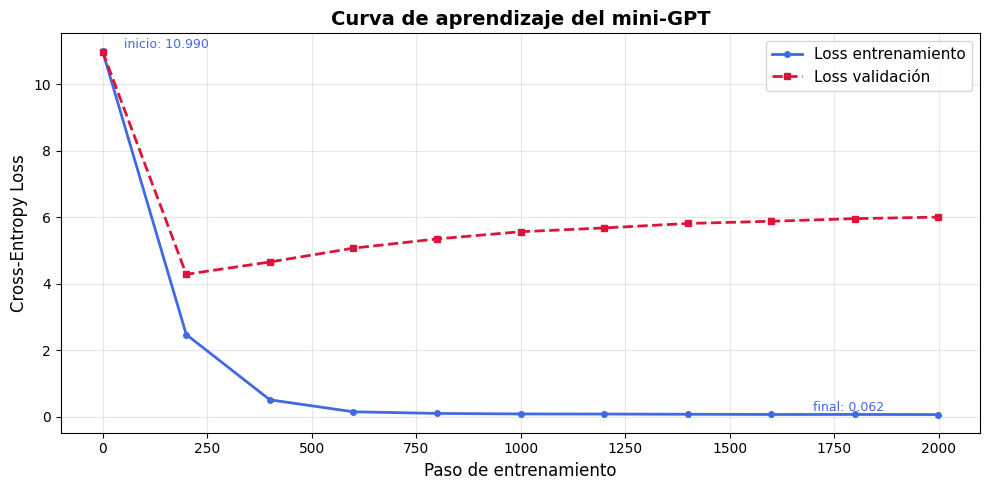

📉 El modelo redujo su pérdida en 10.929 puntos
   Inicio : 10.9904
   Final  : 0.0618


In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(historial_pasos, historial_loss_train,
        label="Loss entrenamiento", color="royalblue",  linewidth=2, marker="o", markersize=4)
ax.plot(historial_pasos, historial_loss_val,
        label="Loss validación",    color="crimson",    linewidth=2, marker="s", markersize=4,
        linestyle="--")

ax.set_xlabel("Paso de entrenamiento", fontsize=12)
ax.set_ylabel("Cross-Entropy Loss",    fontsize=12)
ax.set_title("Curva de aprendizaje del mini-GPT", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Anotar valores inicial y final
ax.annotate(f"inicio: {historial_loss_train[0]:.3f}",
            xy=(historial_pasos[0], historial_loss_train[0]),
            xytext=(historial_pasos[0] + 50, historial_loss_train[0] + 0.1),
            fontsize=9, color="royalblue")
ax.annotate(f"final: {historial_loss_train[-1]:.3f}",
            xy=(historial_pasos[-1], historial_loss_train[-1]),
            xytext=(historial_pasos[-1] - 300, historial_loss_train[-1] + 0.1),
            fontsize=9, color="royalblue")

plt.tight_layout()
plt.show()

mejora = historial_loss_train[0] - historial_loss_train[-1]
print(f"📉 El modelo redujo su pérdida en {mejora:.3f} puntos")
print(f"   Inicio : {historial_loss_train[0]:.4f}")
print(f"   Final  : {historial_loss_train[-1]:.4f}")

---
## 9. Generar texto con el modelo entrenado

¡Llegó el momento de ver qué aprendió el modelo!  
Usaremos la función `generar()` que implementamos antes.

### ¿Cómo funciona la generación?

La generación es **autorregresiva**: el modelo predice un token, ese token se agrega al contexto, y entonces predice el siguiente, y así sucesivamente:

```
"La inteli" → predice "g" → "La intelig"
"La intelig" → predice "e" → "La intelige"
"La intelige" → predice "n" → "La intligen"
...
```

### El parámetro `temperatura`

- **temp < 1**: más conservador, texto más coherente pero repetitivo
- **temp = 1**: distribución original del modelo
- **temp > 1**: más aleatorio, texto más variado pero puede volverse incoherente

In [33]:
prompt = str(input("\n✍️  Escribe un prompt para que el modelo genere texto: "))

In [37]:
prompt = str(input("\n✍️  Escribe un prompt para que el modelo genere texto: "))

def generar_texto(
    modelo,
    texto_inicio: str = prompt,
    n_tokens: int     = 200,
    temperatura: float = 0.8
) -> str:
    """
    Helper que convierte texto inicial → tokens → genera → decodifica.
    """
    modelo.eval()

    # Codificar el texto de inicio
    tokens_inicio = torch.tensor(
        encode(texto_inicio),
        dtype=torch.long,
        device=device
    ).unsqueeze(0)  # shape (1, T)

    # Generar tokens nuevos
    tokens_generados = modelo.generar(
        tokens_inicio,
        max_nuevos_tokens = n_tokens,
        temperatura       = temperatura
    )

    # Decodificar todo el texto resultante
    texto_generado = decode(tokens_generados[0].tolist())
    return texto_generado


# ─── Probar con diferentes temperaturas ──────────────────────────────────────
print("🎨 Generación de texto con diferentes temperaturas\n")

configs_temp = [
    {"temperatura": 0.7, "label": "Conservador (temp=0.7)"},
    {"temperatura": 1.0, "label": "Neutral    (temp=1.0)"},
    {"temperatura": 1.1, "label": "Creativo   (temp=1.1)"},
]

for cfg in configs_temp:
    texto = generar_texto(
        modelo,
        texto_inicio = prompt,
        n_tokens     = 300,
        temperatura  = cfg["temperatura"]
    )
    print(f"🌡️  {cfg['label']}:")
    print(f"{'─'*60}")
    print(texto)
    print()

🎨 Generación de texto con diferentes temperaturas

🌡️  Conservador (temp=0.7):
────────────────────────────────────────────────────────────
la estrategia es ser diferente. No alcanza con hacer lo mismo que todos de manera apenas mas eficiente. Es necesario elegir actividades que constituyan una fuente real de ventaja. En este punto se introducen dos conceptos complementarios. El primero son los trade-offs, que recuerdan que toda estrategia implica decidir que no se va a hacer; elegir un camino supone renunciar a otros. El segundo son los fit drivers, es decir, los ajustes necesarios en la organizacion y en los procesos para que las actividades estrategicas puedan ejecutarse con el nivel de desempeño esperado. En otras palabras, no basta con definir una ventaja; tambien es necesario alinear la empresa para sostenerla.

Hacia el final se integra todo en la logica del modelo de negocio. Se plantea que un negocio orientado a concretar la vision se estructura a partir de relaciones causales

---
## 10. Perplexity: midiendo la calidad del modelo

La **perplexity** (perplejidad) es la métrica estándar para evaluar modelos de lenguaje.

### ¿Qué mide la perplexity?

Intuitivamente: **cuántas opciones igualmente probables tiene el modelo en cada posición**.

$$\text{PPL} = e^{\mathcal{L}} = e^{\text{cross-entropy loss}}$$

| Perplexity | Interpretación |
|---|---|
| PPL = 1 | Predice perfectamente (imposible en la práctica) |
| PPL = vocab_size | Sin aprender nada (distribución uniforme) |
| PPL = 10 | En cada posición elige entre ~10 tokens igualmente probables |
| PPL = 100 | Aún bastante incierto |

> Para referencia: **GPT-4** tiene perplexity < 5 en muchos benchmarks.
> Nuestro mini-modelo con dataset pequeño tendrá valores mucho más altos — y está bien.

In [30]:
@torch.no_grad()
def calcular_perplexity(split: str = "val", n_batches: int = 50) -> float:
    """
    Calcula la perplexity promedio en el conjunto especificado.
    
    PPL = exp(cross_entropy_loss)
    
    Un valor menor indica un modelo mejor.
    PPL == vocab_size sería un modelo que no aprendió nada (distribución uniforme).
    """
    modelo.eval()
    losses = []

    for _ in range(n_batches):
        xb, yb = get_batch(split)
        _, loss = modelo(xb, yb)
        losses.append(loss.item())

    loss_promedio = sum(losses) / len(losses)
    ppl = math.exp(loss_promedio)  # PPL = e^loss
    return ppl


ppl_train = calcular_perplexity("train")
ppl_val   = calcular_perplexity("val")

# Un modelo que no aprendió nada tendría PPL == vocab_size
ppl_baseline = vocab_size  

mejora_relativa = (ppl_baseline - ppl_val) / ppl_baseline * 100

print(f"📊 Perplexity del modelo:")
print(f"   Entrenamiento : {ppl_train:.2f}")
print(f"   Validación    : {ppl_val:.2f}")
print()
print(f"📏 Baseline (sin aprender): {ppl_baseline:.2f}")
print(f"📈 Mejora relativa        : {mejora_relativa:.1f}% mejor que baseline")
print()
print(f"Interpretación:")
print(f"  Un modelo perfecto tendría PPL=1.")
print(f"  Un modelo sin entrenamiento tendría PPL={ppl_baseline} (= vocab_size).")
print(f"  Nuestro modelo tiene PPL valdación={ppl_val:.1f}.")

📊 Perplexity del modelo:
   Entrenamiento : 1.06
   Validación    : 423.23

📏 Baseline (sin aprender): 50257.00
📈 Mejora relativa        : 99.2% mejor que baseline

Interpretación:
  Un modelo perfecto tendría PPL=1.
  Un modelo sin entrenamiento tendría PPL=50257 (= vocab_size).
  Nuestro modelo tiene PPL valdación=423.2.


---
## 11. Experimentos: ¿cómo mejorar el modelo?

Ahora que entendés la base, podés experimentar con estos cambios para ver cómo impactan en la calidad.

### Experimento A: más datos

El factor más importante en LLMs. Reemplazá `TEXTO` con un archivo más grande:

```python
# Cargar cualquier archivo de texto
with open("mi_libro.txt", "r", encoding="utf-8") as f:
    TEXTO = f.read()
```

### Experimento B: más capacidad del modelo

Subir `D_MODELO`, `N_HEADS`, `N_CAPAS`. Tabla de referencia:

| Config | Params | Entrenamiento |
|---|---|---|
| D=64, H=2, L=2 | ~50K | <1 min CPU |
| D=128, H=4, L=4 | ~500K | ~5 min CPU |
| D=256, H=8, L=6 | ~3M | ~30 min CPU |
| D=512, H=8, L=8 | ~12M | GPU recomendada |

### Experimento C: ajustar el learning rate

```python
# Con un scheduler que reduce el LR con cada paso
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizador, T_max=N_PASOS)
# Agregar scheduler.step() al final de cada paso de entrenamiento
```

### Experimento D: tokenización BPE (subpalabras)

```python
# Tokenizador de Hugging Face (BPE, más eficiente que character-level)
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokens = tokenizer.encode(TEXTO)
# vocab_size = tokenizer.vocab_size  # ~50,000
```

### Experimento E: guardar y cargar el modelo

```python
# Guardar
torch.save(modelo.state_dict(), "mini_gpt.pth")

# Cargar
modelo_cargado = MiniGPT().to(device)
modelo_cargado.load_state_dict(torch.load("mini_gpt.pth", map_location=device))
```

In [31]:
# ─── Scheduler de learning rate coseno (Experimento C) ────────────────────────
# Descomentar para usar en el próximo entrenamiento

# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#     optimizador,
#     T_max    = N_PASOS,
#     eta_min  = 1e-6
# )
# # Al final del loop agregar: scheduler.step()

# ─── Guardar el modelo entrenado ─────────────────────────────────────────────
ruta_guardado = "mini_gpt_entrenado.pth"
torch.save({
    "model_state_dict": modelo.state_dict(),
    "config": {
        "d_modelo"  : D_MODELO,
        "n_heads"   : N_HEADS,
        "n_capas"   : N_CAPAS,
        "contexto"  : CONTEXTO,
        "vocab_size": vocab_size,
        "tokenizer" : "gpt2_bpe_tiktoken",   # enc = tiktoken.get_encoding("gpt2")
    },
    "loss_final_train": historial_loss_train[-1],
    "loss_final_val"  : historial_loss_val[-1],
}, ruta_guardado)

import os
tamaño_kb = os.path.getsize(ruta_guardado) / 1024
print(f"💾 Modelo guardado en: {ruta_guardado}")
print(f"   Tamaño: {tamaño_kb:.1f} KB ({n_params:,} parámetros)")

# ─── Cargar el modelo ─────────────────────────────────────────────────────────
print(f"\n⏳ Probando carga del modelo guardado...")
checkpoint = torch.load(ruta_guardado, map_location=device, weights_only=False)

modelo_cargado = MiniGPT().to(device)
modelo_cargado.load_state_dict(checkpoint["model_state_dict"])
modelo_cargado.eval()

print(f"✅ Modelo cargado correctamente")
print(f"   Configuración: D={checkpoint['config']['d_modelo']}, "
      f"H={checkpoint['config']['n_heads']}, "
      f"L={checkpoint['config']['n_capas']}")
print(f"   Tokenizador  : {checkpoint['config']['tokenizer']}")

# Probar generación con el modelo cargado
texto_prueba = generar_texto(modelo_cargado, "El aprendizaje", n_tokens=100)
print(f"\n✍️  Generación de prueba:")
print(f"{texto_prueba}")


💾 Modelo guardado en: mini_gpt_entrenado.pth
   Tamaño: 113402.2 KB (28,954,705 parámetros)

⏳ Probando carga del modelo guardado...
✅ Modelo cargado correctamente
   Configuración: D=256, H=4, L=4
   Tokenizador  : gpt2_bpe_tiktoken

✍️  Generación de prueba:
El aprendizaje y crecimiento, mejoran los procesos internos; cuando los procesos se ejecutan bien, mejora la propuesta de valor al cliente; y cuando mejora la percepcion del cliente, se traducen mejores resultados financieros. Por esto se enfatiza el mapa estrategico: permite mostrar de manera grafica como


---
## 12. Conclusiones y próximos pasos

### Lo que construiste en este notebook

✅ **Tokenizador** character-level: texto ↔ secuencia de enteros  
✅ **Dataset con ventana deslizante**: pares (contexto → siguiente token)  
✅ **Self-Attention causal**: el mecanismo core del Transformer  
✅ **Multi-Head Attention**: múltiples heads especializados en paralelo  
✅ **Feed-Forward Network**: procesamiento no-lineal por token  
✅ **Bloque Transformer completo** con LayerNorm y conexiones residuales  
✅ **miniGPT** ensamblado con embeddings de token y posición  
✅ **Loop de entrenamiento** con AdamW, gradient clipping y evaluación  
✅ **Curva de pérdida** train/val para diagnosticar el aprendizaje  
✅ **Generación de texto** autorregresiva con temperatura  
✅ **Perplexity** como métrica estándar de calidad  
✅ **Guardar/cargar** checkpoints del modelo  

---

### La diferencia entre nuestro modelo y GPT-4

| Característica | nuestro mini-GPT | GPT-4 (estimado) |
|---|---|---|
| Parámetros | ~500K | ~1 Billón |
| Tokens entrenamiento | ~3,000 | ~13 Trillones |
| Contexto | 64 tokens | 128K tokens |
| Capas | 4 | ~120 |
| D_modelo | 128 | ~12,288 |
| Tiempo entrenamiento | minutos (CPU) | meses (miles de GPUs) |

La **arquitectura** es la misma — la diferencia es **escala**.

---

### Próximos pasos sugeridos

| Paso | Descripción |
|---|---|
| 📦 Dataset real | Descargar [TinyShakespeare](https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt) (~1MB) |
| 🔤 BPE tokenizer | Usar `tiktoken` o `transformers` para tokenización subword |
| 🎓 Fine-tuning | Partir de un modelo pre-entrenado (GPT-2, Llama) y afinar con tus datos |
| 💬 RLHF / SFT | Aprende cómo se alinean los modelos para seguir instrucciones |
| 📚 El paper | Leer ["Attention Is All You Need"](https://arxiv.org/abs/1706.03762) (2017) |
| 🎥 Video | Ver ["Let's build GPT" by Andrej Karpathy](https://youtu.be/kCc8FmEb1nY) |

---

> 🎯 **Tarea:** Modificá el `TEXTO` con un archivo de texto propio (un libro, noticias,  
> código fuente) y reentrenar. Observá cómo cambia el texto generado.